# Crop Recommendation Using Machine Learning for Sustainable Agriculture

The project uses soil nutrient and environmental features to recommend the most suitable crop using machine learning classification models.

Dataset features:
- N: Nitrogen content in soil
- P: Phosphorus content in soil
- K: Potassium content in soil
- temperature: Temperature in Celsius
- humidity: Relative humidity
- ph: Soil pH value
- rainfall: Rainfall in mm
- label: Recommended crop

# 1. Importing Required Libraries

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")

# 2. Loading Dataset

In [4]:
df = pd.read_csv("/content/Crop_recommendation_Dataset.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


# 3. Dataset Information

In [5]:
print("Column names:")
print(df.columns)

print("\nDataset information:")
df.info()

print("\nFirst five rows:")
display(df.head())

Column names:
Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB

First five rows:


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


# 4. Basic Statistical Summary

In [6]:
print("Numerical summary:")
display(df.describe())

print("\nCategorical summary:")
display(df.describe(include="object"))

Numerical summary:


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117



Categorical summary:


,label
count,2200
unique,22
top,rice
freq,100


# 5. Missing Values Analysis

Missing values in each column:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


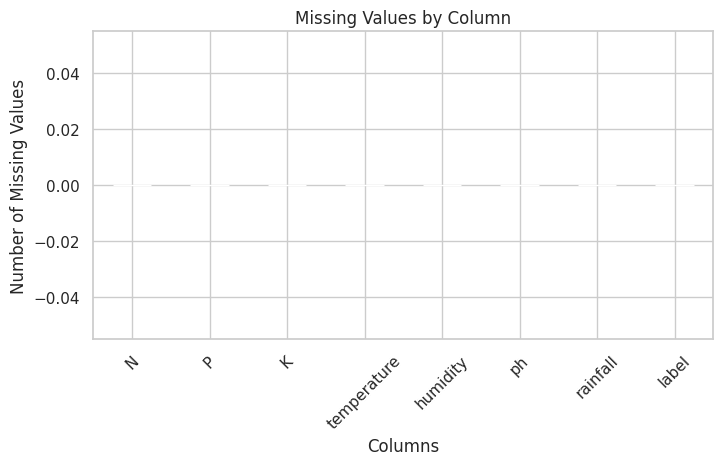

In [7]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

plt.figure(figsize=(8, 4))
missing_values.plot(kind="bar")
plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)
plt.show()

# 6. Duplicate Rows Analysis

In [39]:
duplicate_rows = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_rows)

if duplicate_rows > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")
    print("New dataset shape:", df.shape)
else:
    print("No duplicate rows found.")

Number of duplicate rows: 0
No duplicate rows found.


# 7. Target Variable Analysis

In [9]:
print("Number of crop classes:", df["label"].nunique())

print("\nCrop classes:")
print(df["label"].unique())

print("\nRecords per crop:")
print(df["label"].value_counts())

Number of crop classes: 22

Crop classes:
['rice' 'maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans'
 'mungbean' 'blackgram' 'lentil' 'pomegranate' 'banana' 'mango' 'grapes'
 'watermelon' 'muskmelon' 'apple' 'orange' 'papaya' 'coconut' 'cotton'
 'jute' 'coffee']

Records per crop:
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


# 8. Target Variable Distribution

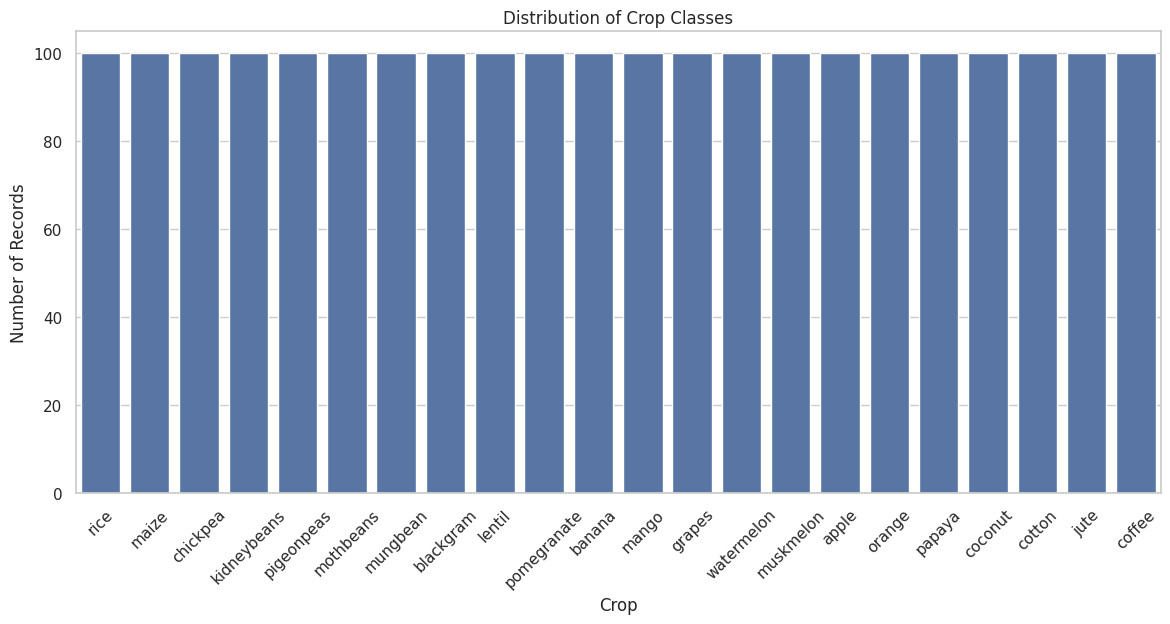

In [10]:
plt.figure(figsize=(14, 6))
sns.countplot(data=df, x="label", order=df["label"].value_counts().index)
plt.title("Distribution of Crop Classes")
plt.xlabel("Crop")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.show()

# 9. Numerical Feature Distribution

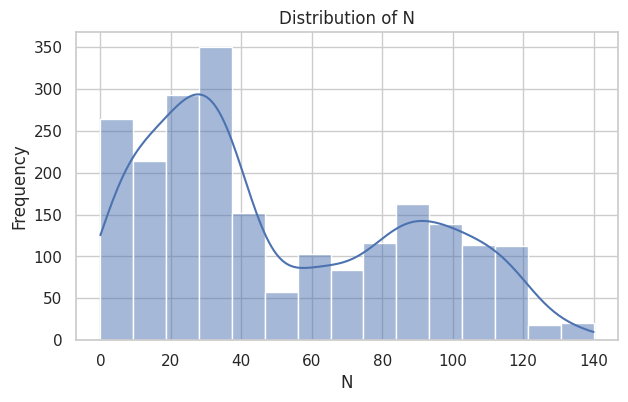

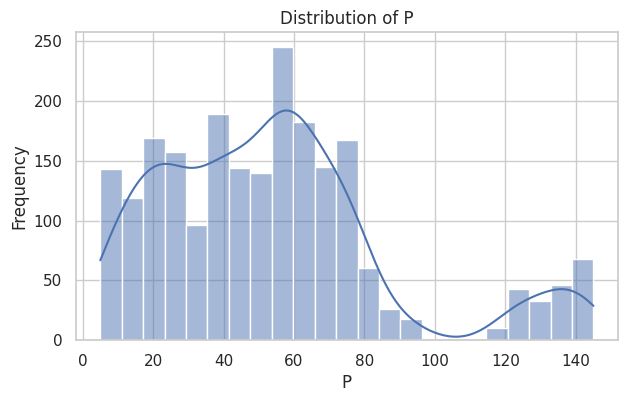

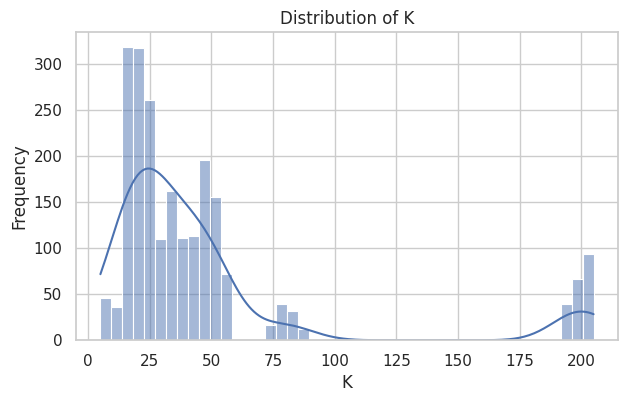

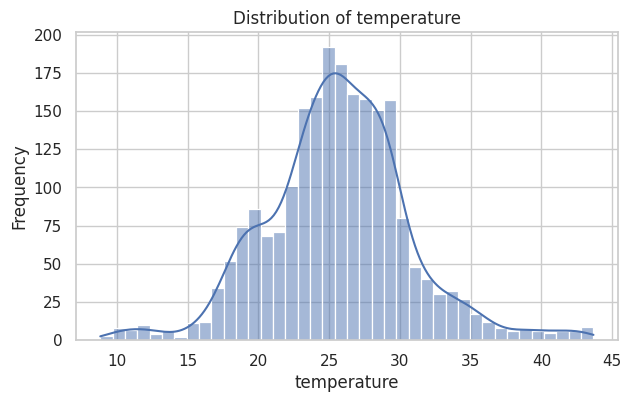

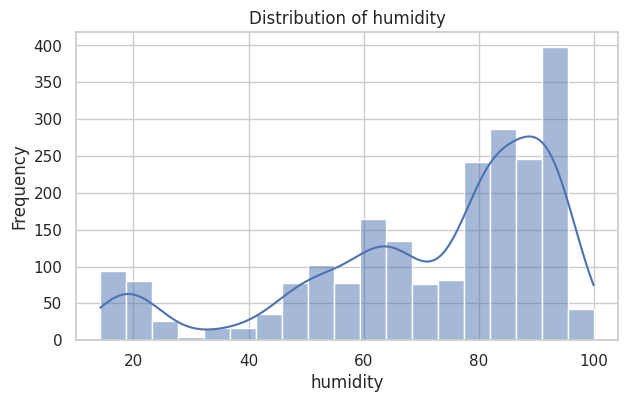

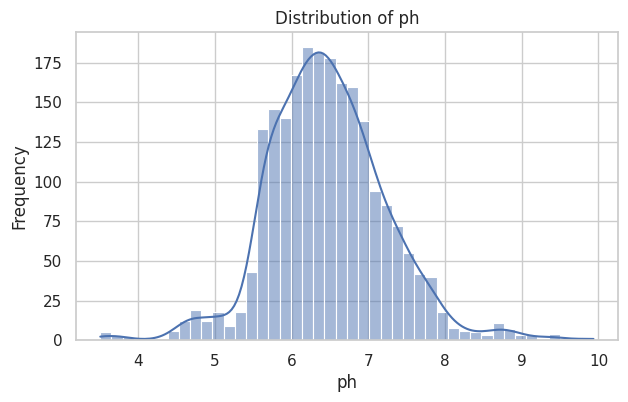

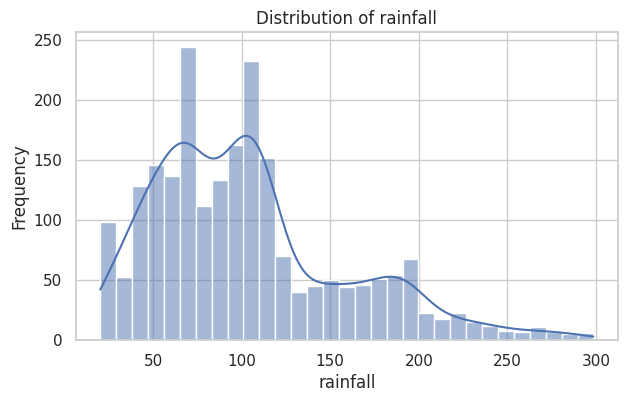

In [11]:
# Numerical Feature Distribution
numerical_features = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]

for feature in numerical_features:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[feature], kde=True)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()

# 10. Boxplots for Numerical Features

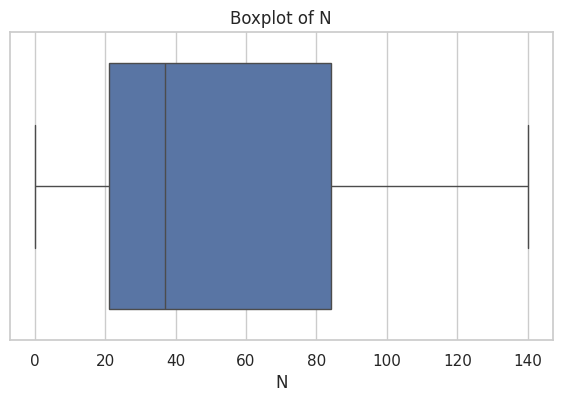

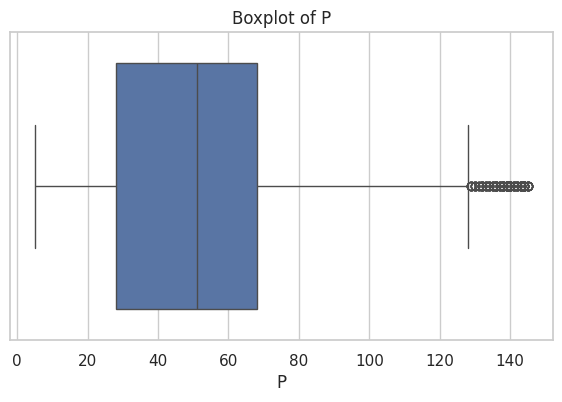

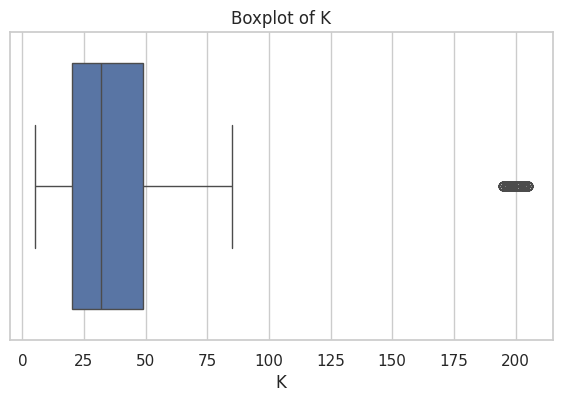

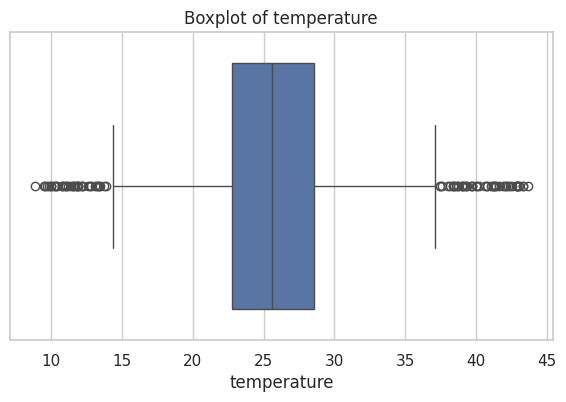

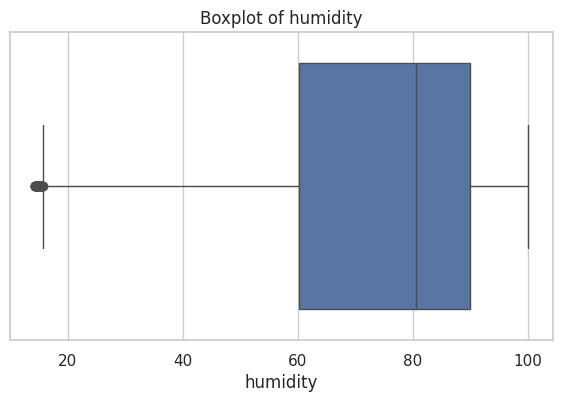

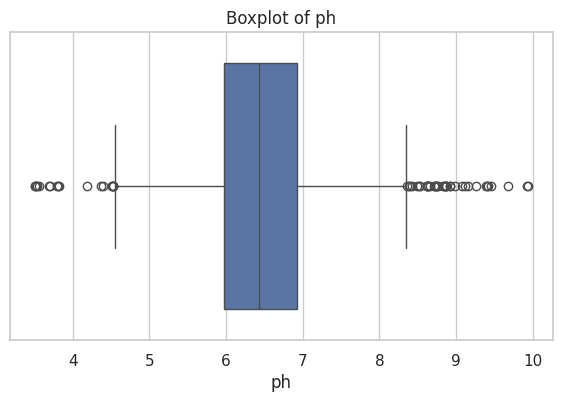

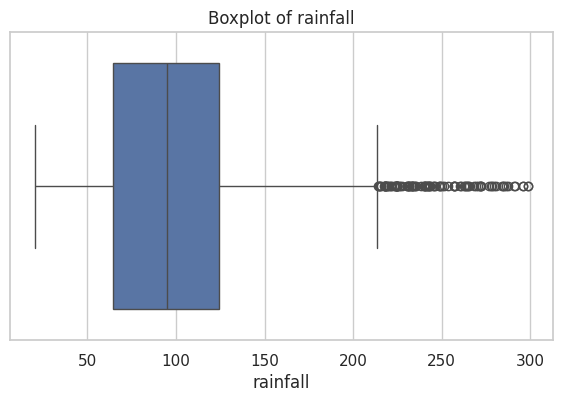

In [40]:
for feature in numerical_features:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x=df[feature])
    plt.title(f"Boxplot of {feature}")
    plt.xlabel(feature)
    plt.show()

# 11. Correlation Heatmap

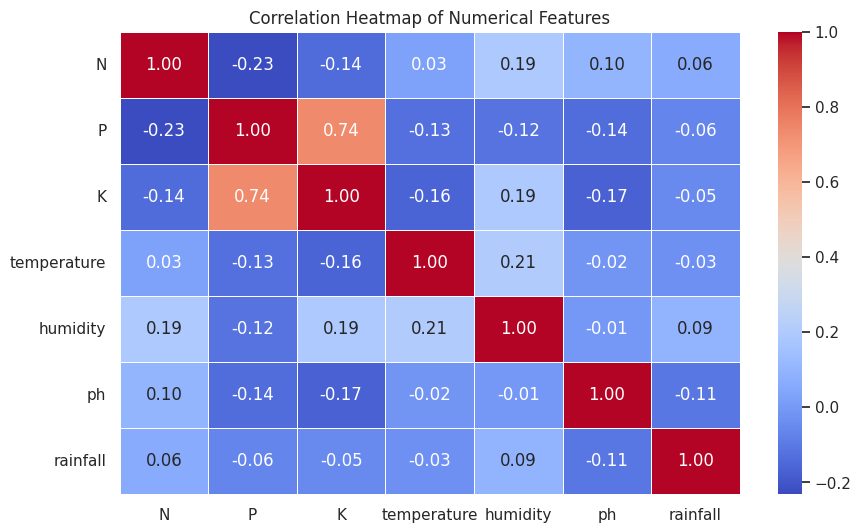

In [13]:
plt.figure(figsize=(10, 6))
correlation_matrix = df[numerical_features].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

# 12. Average N, P, K Values by Crop

,N,P,K
label,,,
cotton,117.77,46.24,19.56
coffee,101.20,28.74,29.94
muskmelon,100.32,17.72,50.08
banana,100.23,82.01,50.05
watermelon,99.42,17.00,50.22
rice,79.89,47.58,39.87
jute,78.40,46.86,39.99
maize,77.76,48.44,19.79
papaya,49.88,59.05,50.04


<Figure size 1400x600 with 0 Axes>

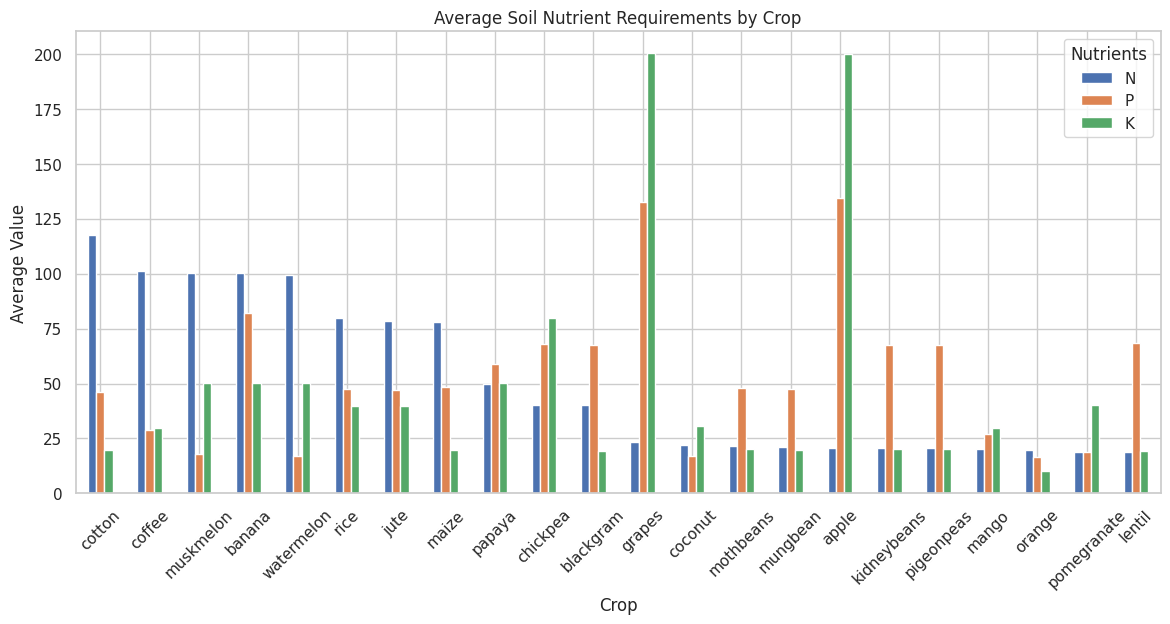

In [14]:
nutrient_means = df.groupby("label")[["N", "P", "K"]].mean().sort_values(by="N", ascending=False)

display(nutrient_means)

plt.figure(figsize=(14, 6))
nutrient_means.plot(kind="bar", figsize=(14, 6))
plt.title("Average Soil Nutrient Requirements by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.legend(title="Nutrients")
plt.show()

# 13. Average Climate Conditions by Crop

,temperature,humidity,ph,rainfall
label,,,,
apple,22.630942,92.333383,5.929663,112.654779
banana,27.376798,80.358123,5.983893,104.626980
blackgram,29.973340,65.118426,7.133952,67.884151
chickpea,18.872847,16.860439,7.336957,80.058977
coconut,27.409892,94.844272,5.976562,175.686646
coffee,25.540477,58.869846,6.790308,158.066295
cotton,23.988958,79.843474,6.912675,80.398043
grapes,23.849575,81.875228,6.025937,69.611829
jute,24.958376,79.639864,6.732778,174.792798


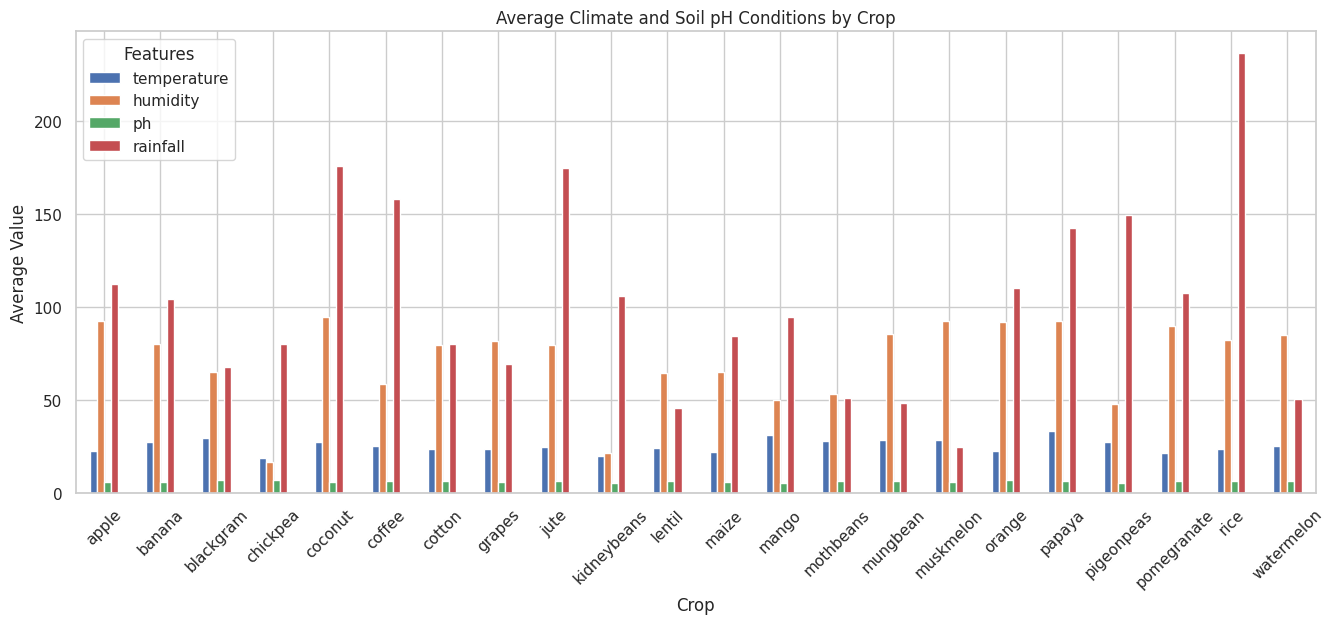

In [15]:
climate_means = df.groupby("label")[["temperature", "humidity", "ph", "rainfall"]].mean()

display(climate_means)

climate_means.plot(kind="bar", figsize=(16, 6))
plt.title("Average Climate and Soil pH Conditions by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.legend(title="Features")
plt.show()

# 14. Rainfall Requirement by Crop

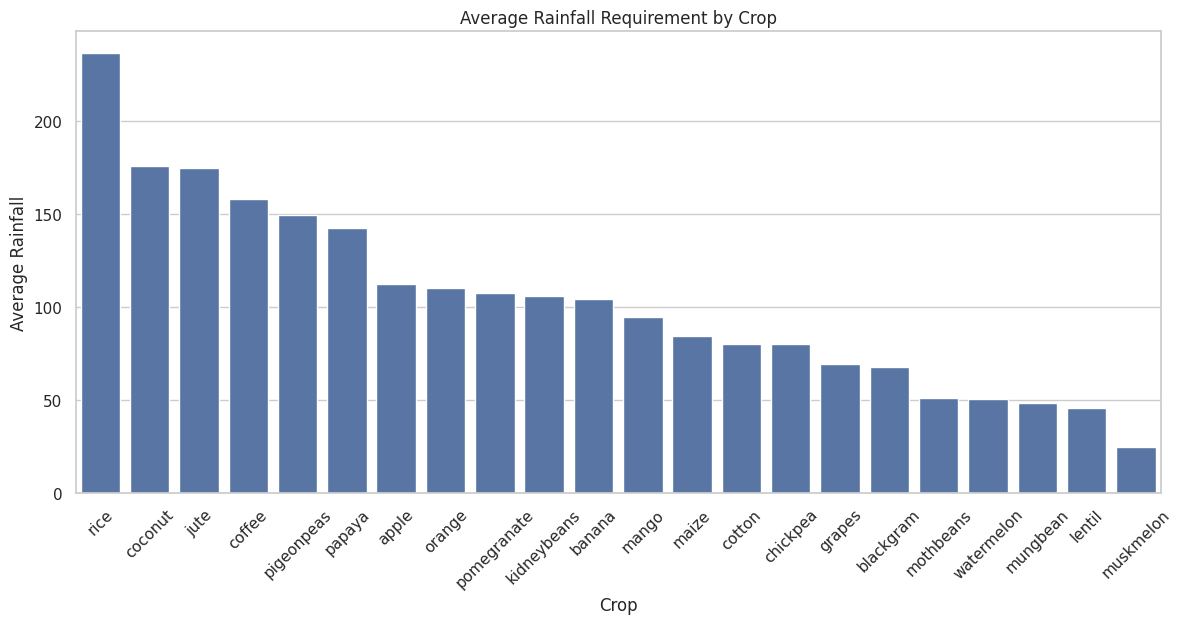

In [16]:
rainfall_by_crop = df.groupby("label")["rainfall"].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(x=rainfall_by_crop.index, y=rainfall_by_crop.values)
plt.title("Average Rainfall Requirement by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Rainfall")
plt.xticks(rotation=45)
plt.show()

# 15. Temperature Requirement by Crop

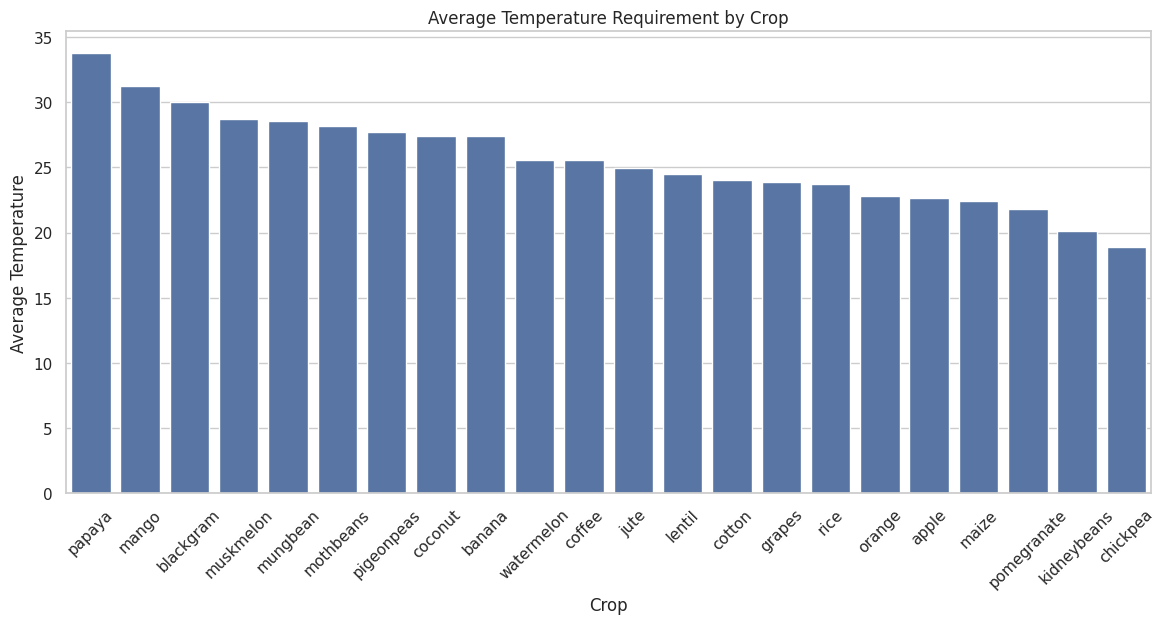

In [17]:
temperature_by_crop = df.groupby("label")["temperature"].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(x=temperature_by_crop.index, y=temperature_by_crop.values)
plt.title("Average Temperature Requirement by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Temperature")
plt.xticks(rotation=45)
plt.show()

# 16. Humidity Requirement by Crop

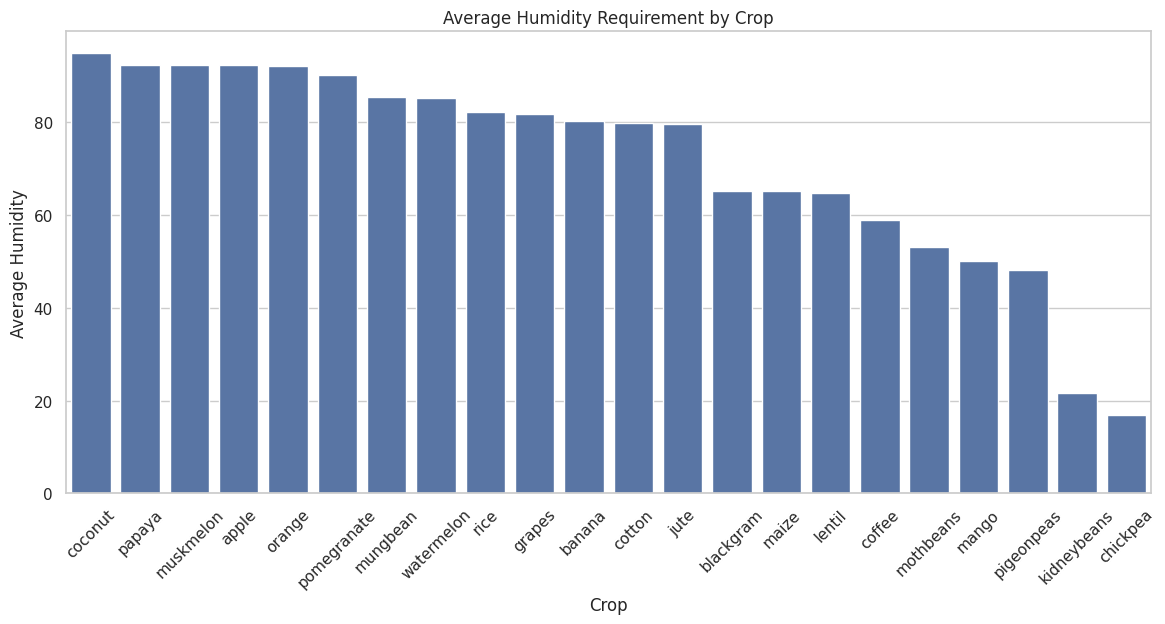

In [18]:
humidity_by_crop = df.groupby("label")["humidity"].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(x=humidity_by_crop.index, y=humidity_by_crop.values)
plt.title("Average Humidity Requirement by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Humidity")
plt.xticks(rotation=45)
plt.show()

# 17. Pairplot of Important Features

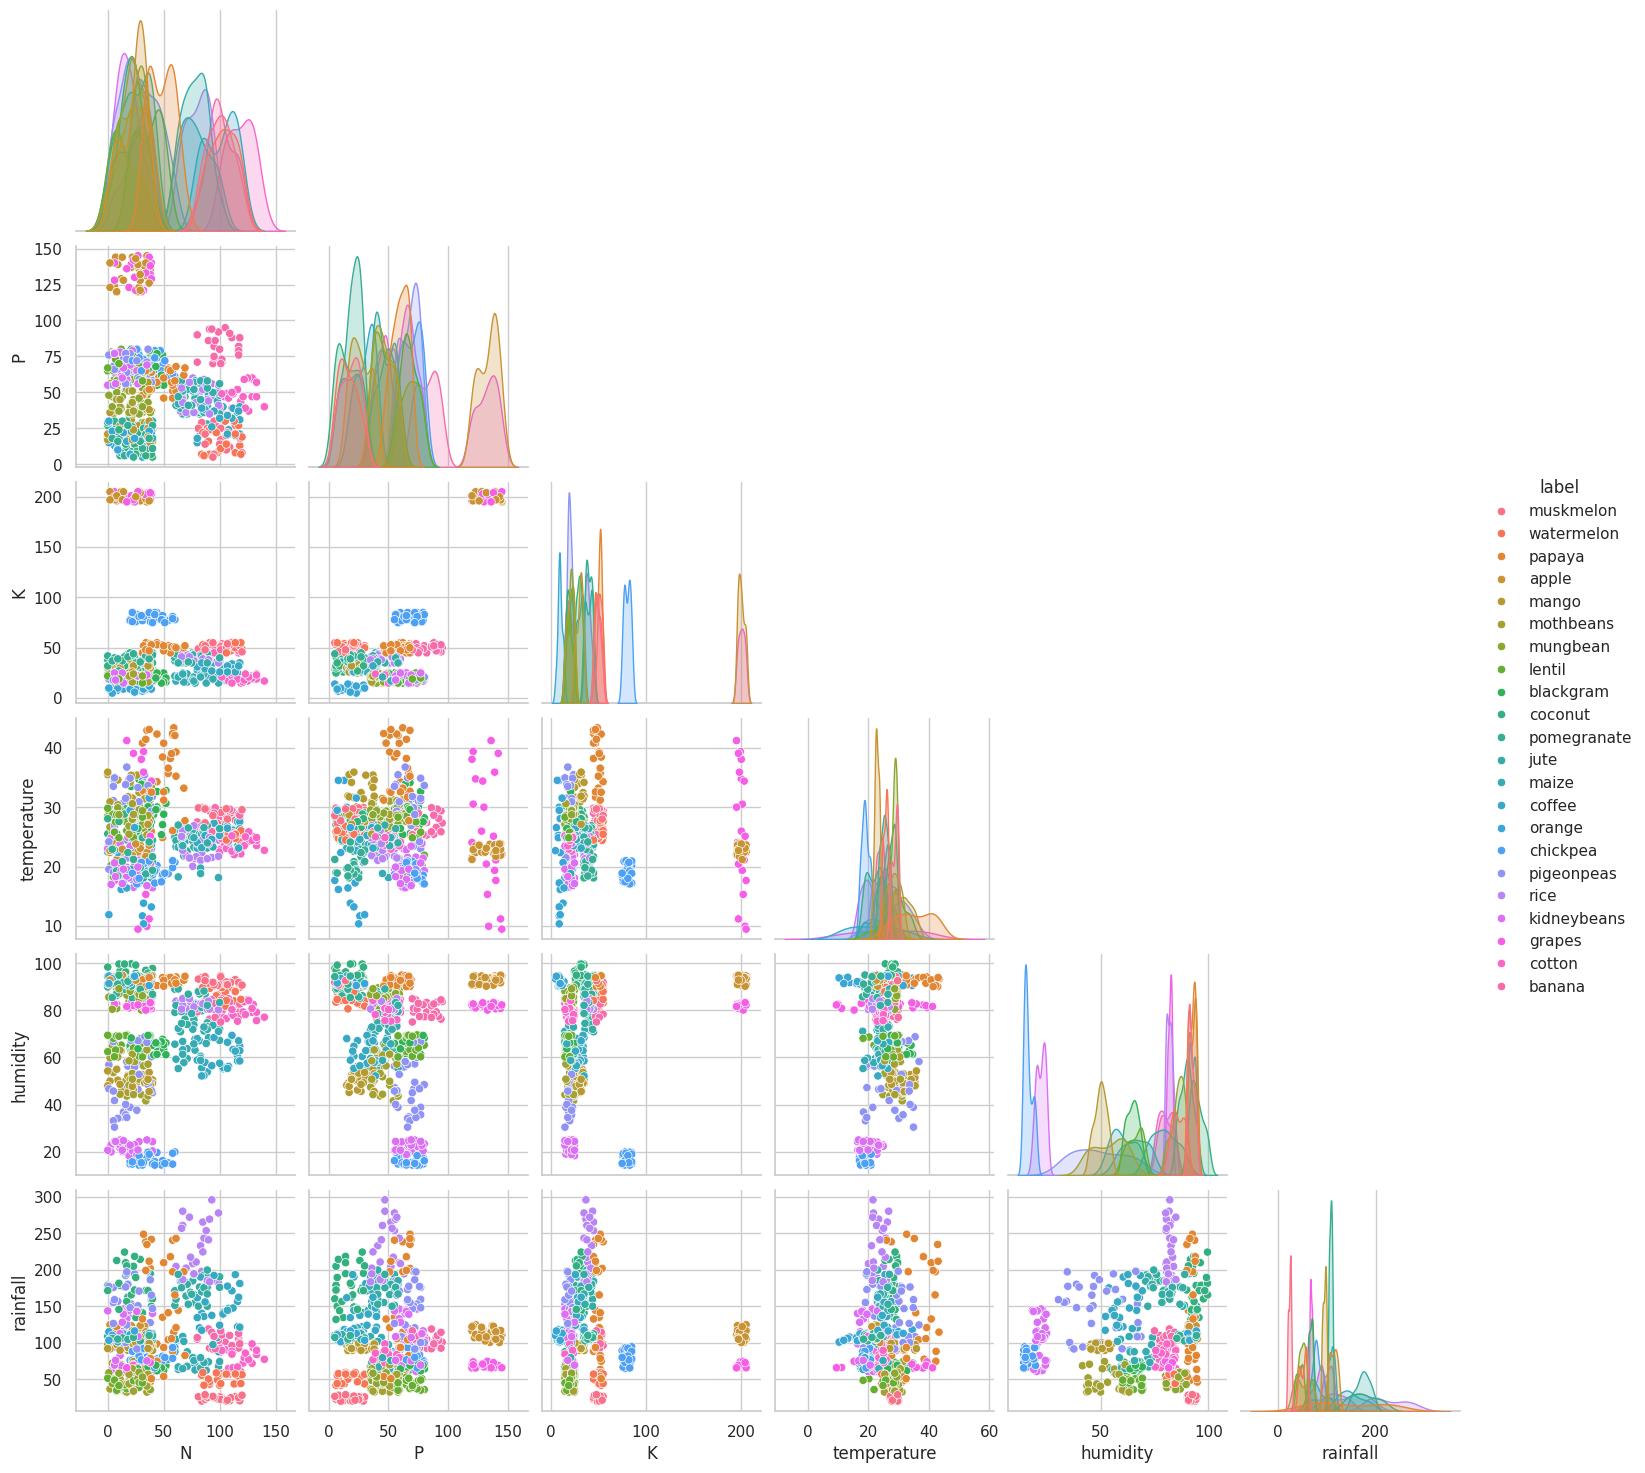

In [20]:
sample_df = df.sample(600, random_state=42)

sns.pairplot(
    sample_df[selected_features],
    hue="label",
    diag_kind="kde",
    corner=True
)

plt.show()

# 18. Key EDA Insights

In [21]:
print("Key EDA Insights:")
print("1. The dataset contains", df.shape[0], "records and", df.shape[1], "columns.")
print("2. There are", df['label'].nunique(), "different crop classes.")
print("3. The dataset has no missing values.")
print("4. The target classes are balanced, with each crop having approximately equal records.")
print("5. N, P, K, temperature, humidity, pH, and rainfall vary across crop types.")
print("6. These variations show that crop recommendation can be treated as a supervised multi-class classification problem.")

Key EDA Insights:
1. The dataset contains 2200 records and 8 columns.
2. There are 22 different crop classes.
3. The dataset has no missing values.
4. The target classes are balanced, with each crop having approximately equal records.
5. N, P, K, temperature, humidity, pH, and rainfall vary across crop types.
6. These variations show that crop recommendation can be treated as a supervised multi-class classification problem.


# 19. Separate Features and Target Variable

In [22]:
X = df.drop("label", axis=1)
y = df["label"]

print("Feature data shape:", X.shape)
print("Target data shape:", y.shape)

print("\nFeatures:")
print(X.columns)

print("\nTarget classes:")
print(y.unique())

Feature data shape: (2200, 7)
Target data shape: (2200,)

Features:
Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall'], dtype='object')

Target classes:
['rice' 'maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans'
 'mungbean' 'blackgram' 'lentil' 'pomegranate' 'banana' 'mango' 'grapes'
 'watermelon' 'muskmelon' 'apple' 'orange' 'papaya' 'coconut' 'cotton'
 'jute' 'coffee']


# 20. Encode Target Labels

In [23]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Original crop labels:")
print(label_encoder.classes_)

print("\nEncoded target examples:")
print(y_encoded[:10])

Original crop labels:
['apple' 'banana' 'blackgram' 'chickpea' 'coconut' 'coffee' 'cotton'
 'grapes' 'jute' 'kidneybeans' 'lentil' 'maize' 'mango' 'mothbeans'
 'mungbean' 'muskmelon' 'orange' 'papaya' 'pigeonpeas' 'pomegranate'
 'rice' 'watermelon']

Encoded target examples:
[20 20 20 20 20 20 20 20 20 20]


# 21. Train-Test Split

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training feature shape: (1760, 7)
Testing feature shape: (440, 7)
Training target shape: (1760,)
Testing target shape: (440,)


# 22. Feature Scaling

In [25]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")
print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Feature scaling completed successfully.
Scaled training data shape: (1760, 7)
Scaled testing data shape: (440, 7)


# 23. View Scaled Data

In [26]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)

display(X_train_scaled_df.head())

,N,P,K,temperature,humidity,ph,rainfall
0,-1.371628,-1.072910,-0.673510,0.819481,0.924395,0.937545,0.199440
1,-1.127411,2.084513,3.015261,0.783251,0.426613,-1.153846,-0.643677
2,-1.073140,0.536162,-0.476250,-0.879968,-2.186291,-1.107452,0.694001
3,-0.340487,-0.465713,-0.594606,0.138043,-0.459237,-0.229482,-1.231744
4,-0.883193,-1.255069,-0.791866,-2.563232,0.915842,-0.341959,0.289941


# 24. Preprocessing Summary

In [27]:
print("Preprocessing Summary")
print("----------------------")
print("Missing values handled: No missing values found")
print("Duplicate rows handled: No duplicate rows found")
print("Target variable encoded using LabelEncoder")
print("Numerical features scaled using StandardScaler")
print("Train-test split: 80% training and 20% testing")
print("Number of training records:", X_train.shape[0])
print("Number of testing records:", X_test.shape[0])
print("Number of crop classes:", len(label_encoder.classes_))

Preprocessing Summary
----------------------
Missing values handled: No missing values found
Duplicate rows handled: No duplicate rows found
Target variable encoded using LabelEncoder
Numerical features scaled using StandardScaler
Train-test split: 80% training and 20% testing
Number of training records: 1760
Number of testing records: 440
Number of crop classes: 22


# 25. Define Machine Learning Models

In [28]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Machine": SVC(probability=True, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

print("Models defined successfully.")
print("Total models:", len(models))

Models defined successfully.
Total models: 6


# 26. Train and Evaluate Models

In [29]:
results = []

for model_name, model in models.items():
    print("Training:", model_name)

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    recall = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

print("All models trained and evaluated successfully.")

Training: Logistic Regression
Training: Decision Tree
Training: Random Forest
Training: K-Nearest Neighbors
Training: Support Vector Machine
Training: Gradient Boosting
All models trained and evaluated successfully.


# 27. Model Comparison Table

In [30]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="F1-Score", ascending=False)

display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score
2,Random Forest,0.995455,0.995671,0.995455,0.995452
5,Gradient Boosting,0.988636,0.989742,0.988636,0.988723
4,Support Vector Machine,0.984091,0.985610,0.984091,0.984038
1,Decision Tree,0.979545,0.980598,0.979545,0.979423
3,K-Nearest Neighbors,0.979545,0.980356,0.979545,0.979283
0,Logistic Regression,0.972727,0.974022,0.972727,0.972464


# 28. Model Comparison Visualisation

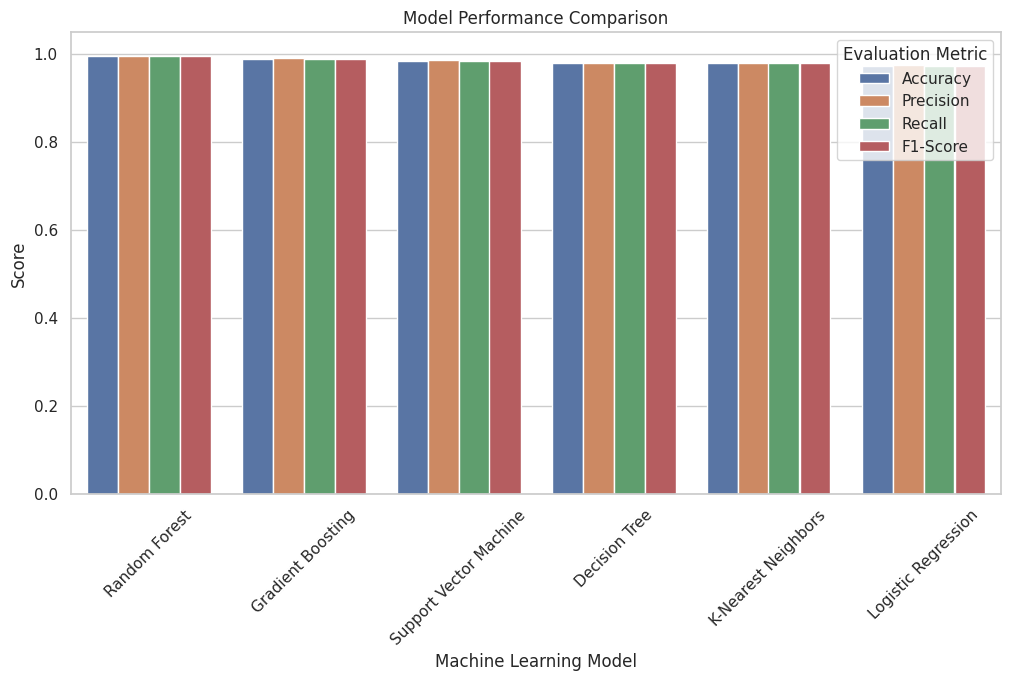

In [31]:
plt.figure(figsize=(12, 6))

results_melted = results_df.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1-Score"],
    var_name="Metric",
    value_name="Score"
)

sns.barplot(data=results_melted, x="Model", y="Score", hue="Metric")

plt.title("Model Performance Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=45)
plt.legend(title="Evaluation Metric")
plt.show()

# 29. Select Best Model

In [32]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

print("Best performing model:", best_model_name)
print("\nBest model scores:")
display(results_df.iloc[0])

Best performing model: Random Forest

Best model scores:


,2
Model,Random Forest
Accuracy,0.995455
Precision,0.995671
Recall,0.995455
F1-Score,0.995452


# 30. Classification Report for Best Model

In [33]:
y_pred_best = best_model.predict(X_test_scaled)

print("Classification Report for:", best_model_name)
print()

print(classification_report(
    y_test,
    y_pred_best,
    target_names=label_encoder.classes_
))

Classification Report for: Random Forest

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      

# 31. Confusion Matrix for Best Model

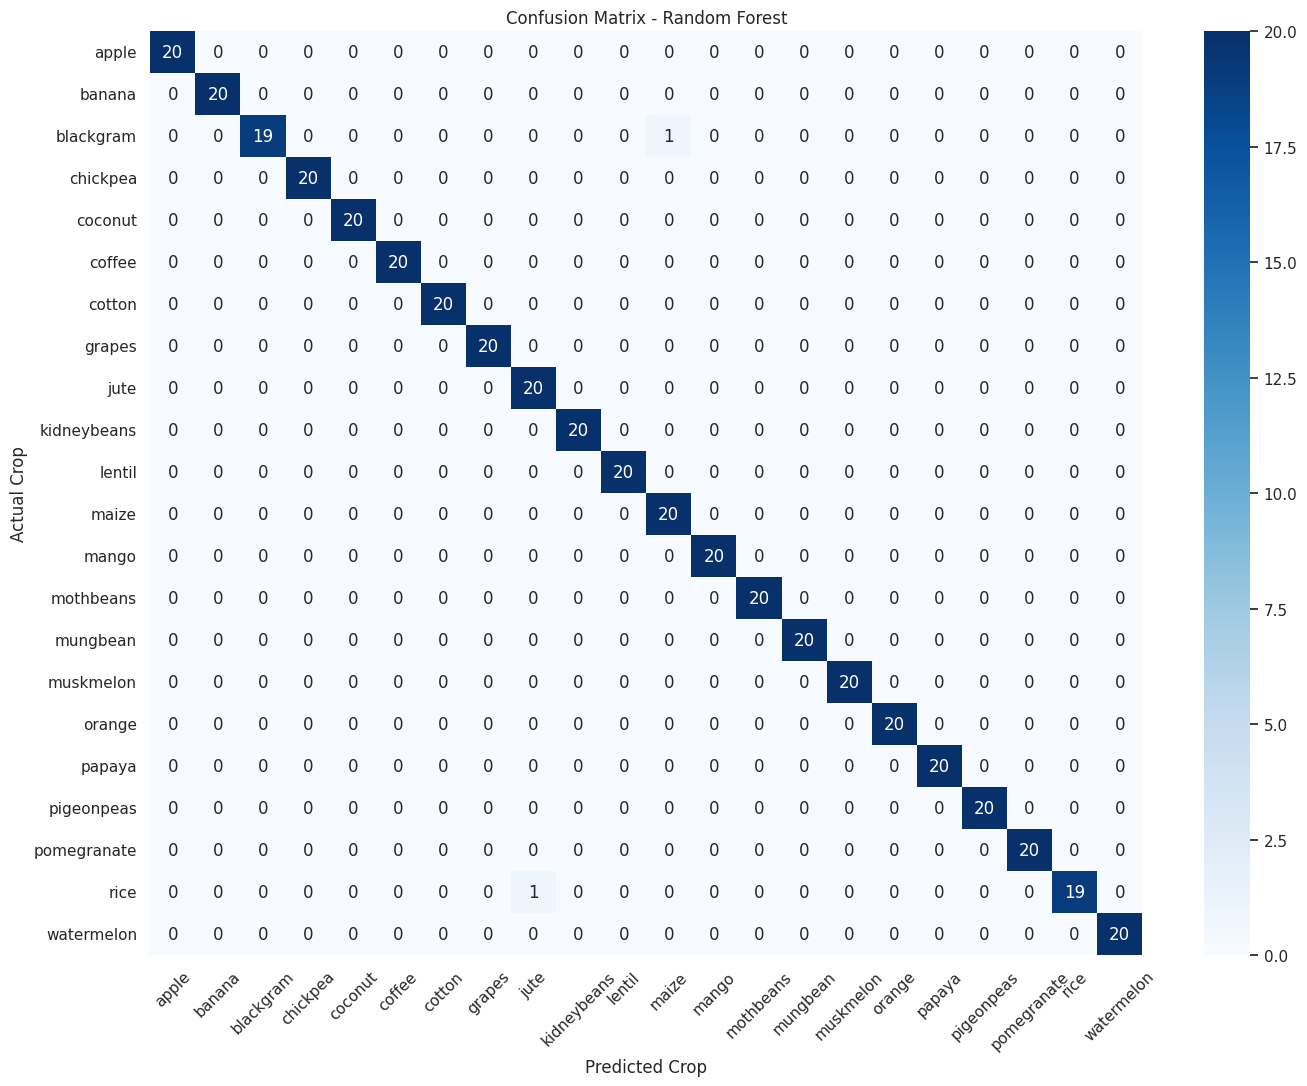

In [34]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(16, 12))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted Crop")
plt.ylabel("Actual Crop")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

# 32. Saving Model Results as CSV

In [36]:
results_df.to_csv("model_comparison_results.csv", index=False)

print("Model comparison results saved as model_comparison_results.csv")

Model comparison results saved as model_comparison_results.csv


# 33. Hyperparameter Tuning for Random Forest

In [41]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_model = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Hyperparameter tuning completed.")
print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation F1-score:")
print(grid_search.best_score_)

Hyperparameter tuning completed.
Best parameters:
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}

Best cross-validation F1-score:
0.9960121483944151


# 34. Evaluate Tuned Random Forest Model

In [42]:
tuned_rf_model = grid_search.best_estimator_

y_pred_tuned = tuned_rf_model.predict(X_test_scaled)

tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_precision = precision_score(y_test, y_pred_tuned, average="weighted")
tuned_recall = recall_score(y_test, y_pred_tuned, average="weighted")
tuned_f1 = f1_score(y_test, y_pred_tuned, average="weighted")

print("Tuned Random Forest Performance")
print("--------------------------------")
print("Accuracy:", tuned_accuracy)
print("Precision:", tuned_precision)
print("Recall:", tuned_recall)
print("F1-Score:", tuned_f1)

Tuned Random Forest Performance
--------------------------------
Accuracy: 0.9954545454545455
Precision: 0.9956709956709956
Recall: 0.9954545454545455
F1-Score: 0.9954517027687759


# 35. Classification Report for Tuned Model

In [43]:
print("Classification Report for Tuned Random Forest")
print()

print(classification_report(
    y_test,
    y_pred_tuned,
    target_names=label_encoder.classes_
))

Classification Report for Tuned Random Forest

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00 

# 36. Confusion Matrix - Tuned Random Forest


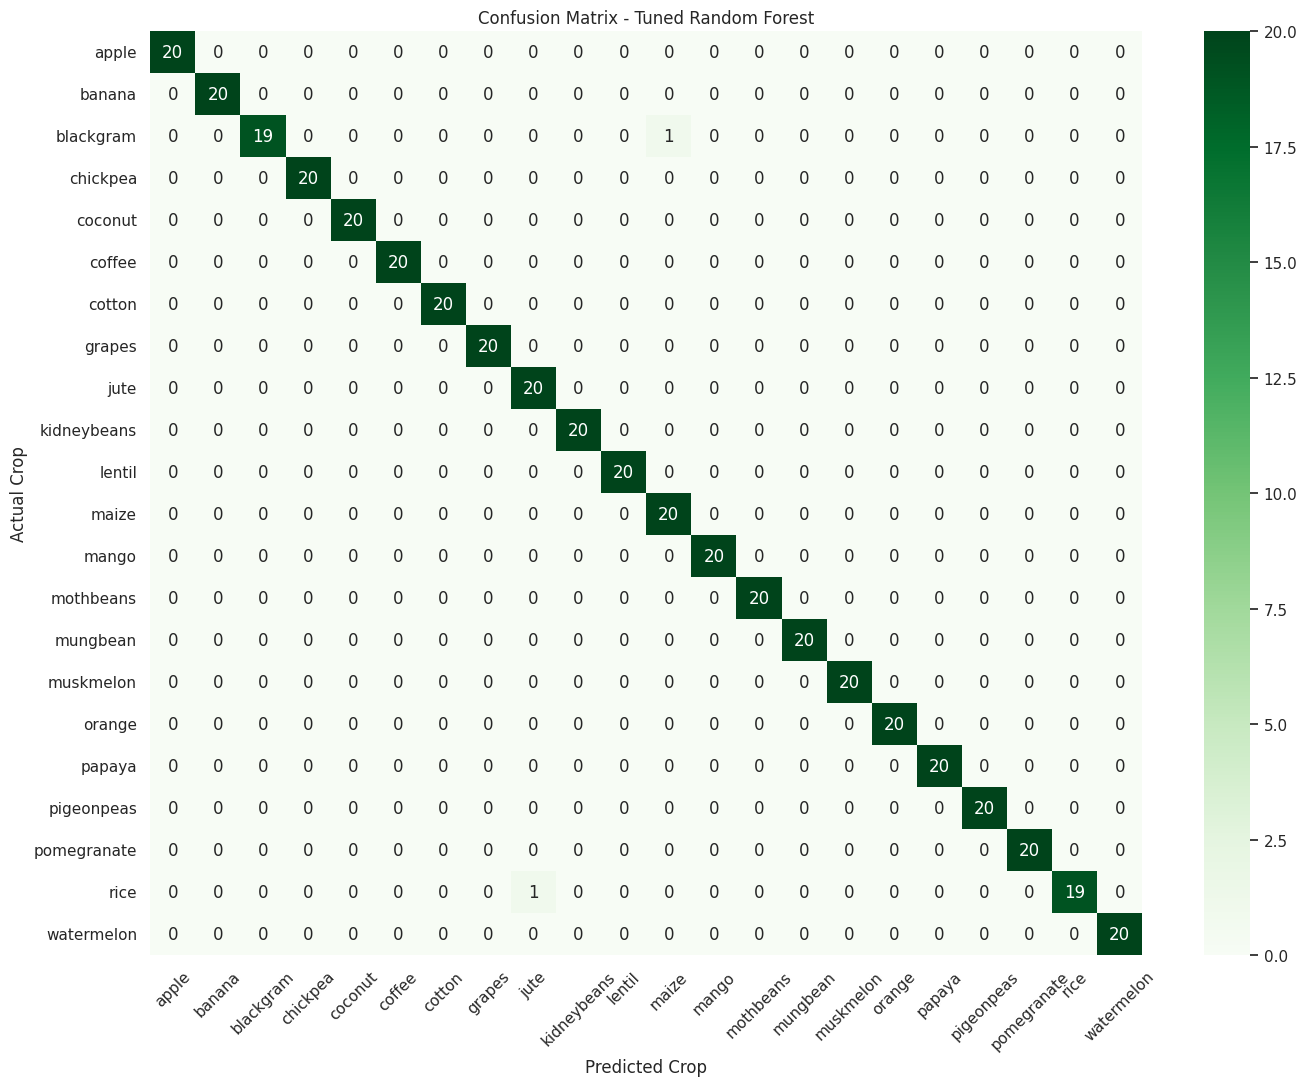

In [44]:
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(16, 12))

sns.heatmap(
    cm_tuned,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix - Tuned Random Forest")
plt.xlabel("Predicted Crop")
plt.ylabel("Actual Crop")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

# 37. Original vs Tuned Random Forest Comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Original Random Forest,0.995455,0.995671,0.995455,0.995452
1,Tuned Random Forest,0.995455,0.995671,0.995455,0.995452


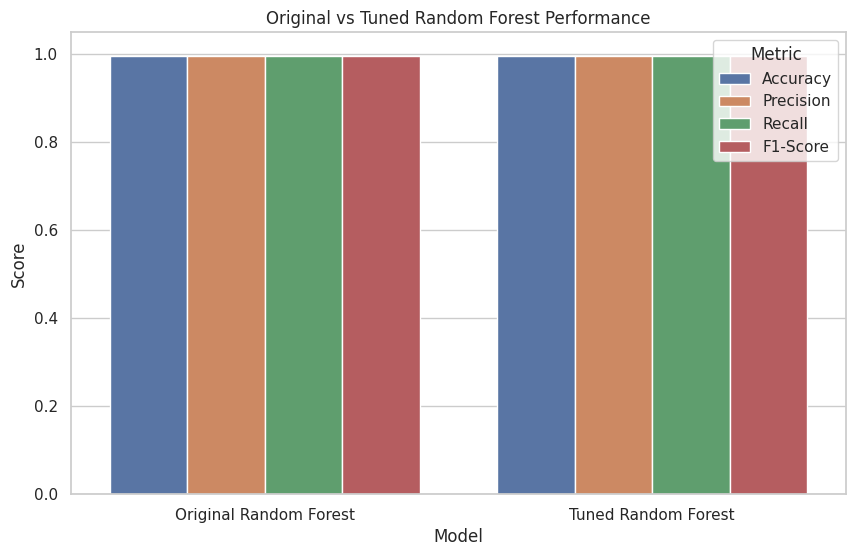

In [45]:
original_rf = results_df[results_df["Model"] == "Random Forest"].iloc[0]

comparison_data = {
    "Model": ["Original Random Forest", "Tuned Random Forest"],
    "Accuracy": [original_rf["Accuracy"], tuned_accuracy],
    "Precision": [original_rf["Precision"], tuned_precision],
    "Recall": [original_rf["Recall"], tuned_recall],
    "F1-Score": [original_rf["F1-Score"], tuned_f1]
}

rf_comparison_df = pd.DataFrame(comparison_data)

display(rf_comparison_df)

rf_comparison_melted = rf_comparison_df.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1-Score"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 6))
sns.barplot(data=rf_comparison_melted, x="Model", y="Score", hue="Metric")
plt.title("Original vs Tuned Random Forest Performance")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.show()

# 38. Feature Importance - Tuned Random Forest

,Feature,Importance
6,rainfall,0.223133
4,humidity,0.216879
2,K,0.183446
1,P,0.145579
0,N,0.101962
3,temperature,0.075522
5,ph,0.053479


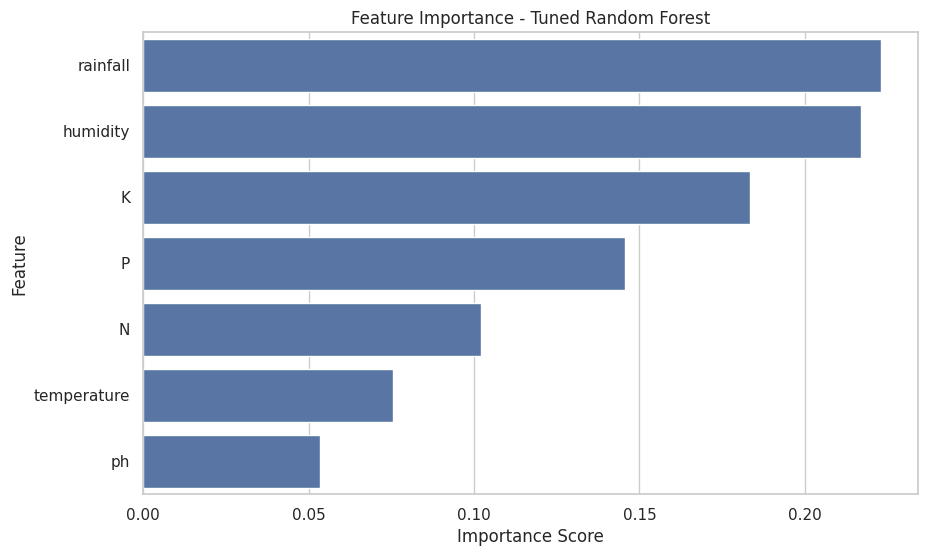

In [46]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tuned_rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x="Importance", y="Feature")
plt.title("Feature Importance - Tuned Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

# 39. Manual Crop Prediction Test

In [47]:
# Example input values
sample_input = pd.DataFrame({
    "N": [90],
    "P": [42],
    "K": [43],
    "temperature": [20.8],
    "humidity": [82.0],
    "ph": [6.5],
    "rainfall": [202.9]
})

sample_input_scaled = scaler.transform(sample_input)

sample_prediction_encoded = tuned_rf_model.predict(sample_input_scaled)

sample_prediction_label = label_encoder.inverse_transform(sample_prediction_encoded)

print("Input soil and environmental conditions:")
display(sample_input)

print("Recommended Crop:", sample_prediction_label[0])

Input soil and environmental conditions:


,N,P,K,temperature,humidity,ph,rainfall
0,90,42,43,20.8,82.0,6.5,202.9


Recommended Crop: rice


# 40. Crop Recommendation Function

In [48]:
def recommend_crop(N, P, K, temperature, humidity, ph, rainfall):
    input_data = pd.DataFrame({
        "N": [N],
        "P": [P],
        "K": [K],
        "temperature": [temperature],
        "humidity": [humidity],
        "ph": [ph],
        "rainfall": [rainfall]
    })

    input_scaled = scaler.transform(input_data)

    prediction_encoded = tuned_rf_model.predict(input_scaled)

    prediction_label = label_encoder.inverse_transform(prediction_encoded)

    return prediction_label[0]


recommended_crop = recommend_crop(
    N=90,
    P=42,
    K=43,
    temperature=20.8,
    humidity=82.0,
    ph=6.5,
    rainfall=202.9
)

print("Recommended Crop:", recommended_crop)

Recommended Crop: rice


# 41. Saving Final Results

In [49]:
final_results = pd.DataFrame({
    "Model": ["Tuned Random Forest"],
    "Accuracy": [tuned_accuracy],
    "Precision": [tuned_precision],
    "Recall": [tuned_recall],
    "F1-Score": [tuned_f1],
    "Best Parameters": [grid_search.best_params_]
})

final_results.to_csv("final_tuned_model_results.csv", index=False)
feature_importance.to_csv("feature_importance.csv", index=False)
rf_comparison_df.to_csv("random_forest_tuning_comparison.csv", index=False)

print("Final results saved successfully.")
print("Files created:")
print("1. final_tuned_model_results.csv")
print("2. feature_importance.csv")
print("3. random_forest_tuning_comparison.csv")

Final results saved successfully.
Files created:
1. final_tuned_model_results.csv
2. feature_importance.csv
3. random_forest_tuning_comparison.csv


# 42. Final Project Summary

In [50]:
print("Final Project Summary")
print("----------------------")
print("Project Title: Crop Recommendation Using Machine Learning for Sustainable Agriculture")
print("Dataset shape:", df.shape)
print("Number of input features:", X.shape[1])
print("Number of crop classes:", len(label_encoder.classes_))
print("Models trained:", len(models))
print("Best tuned model: Random Forest")
print("Final Accuracy:", tuned_accuracy)
print("Final Precision:", tuned_precision)
print("Final Recall:", tuned_recall)
print("Final F1-Score:", tuned_f1)
print("Most important feature:", feature_importance.iloc[0]["Feature"])

Final Project Summary
----------------------
Project Title: Crop Recommendation Using Machine Learning for Sustainable Agriculture
Dataset shape: (2200, 8)
Number of input features: 7
Number of crop classes: 22
Models trained: 6
Best tuned model: Random Forest
Final Accuracy: 0.9954545454545455
Final Precision: 0.9956709956709956
Final Recall: 0.9954545454545455
Final F1-Score: 0.9954517027687759
Most important feature: rainfall
